# Lab 4: Logistic Regression for SMS Spam Detection

In this lab you will build a logistic regression classifier **from scratch** to distinguish spam from legitimate (ham) SMS messages, using the SMS Spam Collection dataset. You will walk through the full machine-learning pipeline: loading and exploring data, preprocessing text, extracting TF-IDF features, implementing logistic regression with gradient descent, adding regularization, evaluating performance, and interpreting the model.

**Dataset:** SMS Spam Collection — a public, tab-separated corpus ([link](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection)). Each row has a label (`ham` or `spam`) and the raw message text. Download the file `SMSSpamCollection` and place it in your working directory.

**Learning Objectives:**
- Implement the core building blocks of logistic regression (sigmoid, cross-entropy loss, gradient descent).
- Preprocess text and compute TF-IDF features manually.
- Apply L2 regularization and understand its effect on weights and generalization.
- Evaluate a classifier with precision, recall, F1-score, and the confusion matrix.
- Inspect learned weights for model interpretability.


## Instructions

Complete each section marked with `# TODO` by replacing the `...` placeholders with your code. The notebook is designed to be run **sequentially** — later questions depend on earlier ones.

**Rules & Tips:**
- You may use `pandas`, `numpy`, `matplotlib`, and `scikit-learn` (for evaluation metrics and train/test split only). The logistic regression model itself must be coded from scratch.
- Test intermediate outputs with `print` to catch bugs early.
- Before submission, **Kernel → Restart & Run All** to make sure everything executes cleanly.


<div class="alert alert-block alert-info">
<h3>Student Information</h3> Please provide information about yourself.<br>
<b>Name</b>: Raj Shah<br> 
<b>NetID</b>: ras637<br>
<b>Recitation #</b>: 01:198:439:05<br>
<b>Notes to Grader</b> (optional):<br>
<br><br>
<b>IMPORTANT</b>
Your work will not be graded without your initials below<br>
I certify that this lab represents my own work and I have read the RU academic intergrity policies at<br>
<a href="https://www.cs.rutgers.edu/academic-integrity/introduction">https://www.cs.rutgers.edu/academic-integrity/introduction </a><br>
<b>Initials</b>: RS     (eg: NC for Naina Chaturvedi)
</div>

## Question 1: Loading and Exploring the Dataset

Before building any model we need to load and understand the data. Knowing the structure and class distribution helps anticipate issues like class imbalance.

**Tasks:**
- Load `SMSSpamCollection` into a DataFrame with columns `'label'` and `'message'`.
- Display the first 5 rows.
- Print the count of ham vs. spam messages and the **spam percentage**.

**Hint:** Use `pd.read_csv` with `sep='\t'` and `encoding='latin1'`. Use `value_counts()` for label counts.


In [1]:
# Environment setup — run this cell first
# Fixes potential matplotlib compatibility issues in some conda environments
import subprocess, sys
try:
    import matplotlib
    if tuple(int(x) for x in matplotlib.__version__.split('.')[:2]) < (3, 7):
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'matplotlib'])
        print('matplotlib upgraded. Please restart the kernel and run all cells again.')
    else:
        print(f'matplotlib {matplotlib.__version__} — OK')
except Exception as e:
    print(f'Note: {e}. If you see plotting errors later, run: pip install --upgrade matplotlib')


matplotlib 3.10.8 — OK


In [2]:
import pandas as pd

# TODO: Load the dataset
df = pd.read_csv("SMSSpamCollection.txt", sep='\t', header=None, names=['label', 'message'], encoding='latin1')

# TODO: Display the first 5 rows
display(df.head())


# TODO: Print label counts and spam percentage
label_counts = df['label'].value_counts()
print(label_counts)
print(f"Spam percentage: {label_counts['spam'] / len(df) * 100:.1f}%")


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64
Spam percentage: 13.4%


## Question 2: Preprocessing — Tokenization and Normalization

Raw text must be cleaned before it can be converted to numerical features. Here you will build a simple preprocessing pipeline.

**Tasks:**
- Implement `preprocess_text(text)` to:
  1. Convert to lowercase.
  2. Remove all punctuation characters.
  3. Split on whitespace to produce a list of tokens.
- Apply it to the `'message'` column, storing results in a new `'tokens'` column.
- Print the tokens of the first message to verify.

**Hint:** `string.punctuation` + `str.translate` is an efficient way to strip punctuation.


In [3]:
import string

def preprocess_text(text):
    # TODO: Implement this function
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Tokenize by splitting on whitespace
    tokens = text.split()
    return tokens

# TODO: Apply the function to the 'message' column
df['tokens'] = df['message'].apply(preprocess_text)

# TODO: Print the tokens for the first message
print(df['tokens'].iloc[0])


['go', 'until', 'jurong', 'point', 'crazy', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'there', 'got', 'amore', 'wat']


## Question 3: Splitting the Data

We need separate training and test sets to evaluate generalization. Because the dataset is imbalanced, use **stratified** splitting to keep the spam ratio consistent across both sets.

**Tasks:**
- Split into 80% train / 20% test with stratification on the label column.
- Map labels: `'ham' → 0`, `'spam' → 1`.
- Extract `y_train` and `y_test` arrays.
- Print the sizes and spam percentages of both sets.

**Hint:** `train_test_split(..., stratify=df['label'], random_state=42)`.


In [4]:
from sklearn.model_selection import train_test_split

# TODO: Split the data (stratified)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# Map labels to 0 and 1
train_df = train_df.copy()
test_df = test_df.copy()
train_df['label_num'] = train_df['label'].map({'ham': 0, 'spam': 1})
test_df['label_num'] = test_df['label'].map({'ham': 0, 'spam': 1})

# Extract labels
y_train = train_df['label_num'].values
y_test = test_df['label_num'].values

# TODO: Print sizes and spam percentages for both sets
print(f"Train size: {len(train_df)}, spam%: {y_train.mean()*100:.1f}%")
print(f"Test  size: {len(test_df)},  spam%: {y_test.mean()*100:.1f}%")


Train size: 4457, spam%: 13.4%
Test  size: 1115,  spam%: 13.4%


## Question 4: Computing TF-IDF Features

Transform tokenized messages into TF-IDF (Term Frequency–Inverse Document Frequency) vectors. We limit the vocabulary to the **top 1200** most frequent words from the training set.

**Formulas:**
$$\text{TF}(w, d) = \frac{\text{count of } w \text{ in } d}{\text{total tokens in } d}$$
$$\text{IDF}(w) = \log\!\left(\frac{N}{1 + \text{DF}(w)}\right)$$

**Tasks:**
- Build the vocabulary (top 1200 words by frequency in training data).
- Compute IDF for each vocabulary word.
- Implement `compute_tfidf(tokens, vocab_set, word_to_idx, idf)`.
- Build feature matrices `X_train` and `X_test`; print their shapes.

**Hint:** Use `Counter` for frequencies. Create a `vocab_set = set(vocab)` for O(1) membership checks inside `compute_tfidf`.


In [5]:
from collections import Counter
import numpy as np

# Step 1: Build vocabulary from training set
# TODO: Flatten all training tokens into one list
all_words = [word for tokens in train_df['tokens'] for word in tokens]

# TODO: Get the 1200 most common words
word_counts = Counter(all_words)
vocab = [w for w, _ in word_counts.most_common(1200)]

word_to_idx = {word: i for i, word in enumerate(vocab)}
vocab_set = set(vocab)

# Step 2: Compute IDF
# TODO: Count document frequency for each vocab word
df_counts = {word: 0 for word in vocab}
for tokens in train_df['tokens']:
    unique_words = set(tokens)
    for word in unique_words:
        if word in df_counts:
            df_counts[word] += 1

N = len(train_df)
idf = {word: np.log(N / (1 + df_counts[word])) for word in vocab}

# Step 3: TF-IDF function
def compute_tfidf(tokens, vocab_set, word_to_idx, idf):
    tfidf_vector = np.zeros(len(word_to_idx))
    word_count = Counter(tokens)
    total = len(tokens) if len(tokens) > 0 else 1
    for word, count in word_count.items():
        if word in vocab_set:
            idx = word_to_idx[word]
            tf = count / total
            tfidf_vector[idx] = tf * idf[word]
    return tfidf_vector

# TODO: Create X_train and X_test
X_train = np.array([compute_tfidf(tokens, vocab_set, word_to_idx, idf) for tokens in train_df['tokens']])
X_test  = np.array([compute_tfidf(tokens, vocab_set, word_to_idx, idf) for tokens in test_df['tokens']])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


X_train shape: (4457, 1200)
X_test shape:  (1115, 1200)


## Question 5: Implementing Logistic Regression Functions

Implement the three core components from scratch:

1. **Sigmoid:** $\sigma(z) = \frac{1}{1 + e^{-z}}$
2. **Cost (binary cross-entropy):** $J(\mathbf{w}) = -\frac{1}{m}\sum_{i=1}^m \bigl[y_i\log h_i + (1-y_i)\log(1-h_i)\bigr]$ where $h_i = \sigma(\mathbf{x}_i^\top \mathbf{w})$.
3. **Gradient descent:** update rule $\mathbf{w} \leftarrow \mathbf{w} - \alpha\,\frac{1}{m}X^\top(\mathbf{h}-\mathbf{y})$.

**Tasks:**
- Prepend a bias column (column of 1s) to `X_train` and `X_test`.
- Implement `sigmoid`, `compute_cost`, and `gradient_descent`.
- Use `np.clip` inside sigmoid (clip `z` to `[-500, 500]`) and inside cost (clip `h` to `[1e-7, 1-1e-7]`) for numerical stability.

**Hint:** Record the cost every 100 iterations so we can plot convergence later.


In [6]:
# Add bias column (as the FIRST column)
X_train_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_bias  = np.hstack([np.ones((X_test.shape[0], 1)),  X_test])

# TODO: Implement sigmoid function
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# TODO: Implement cost function
def compute_cost(X, y, w):
    m = len(y)
    h = sigmoid(X @ w)
    h = np.clip(h, 1e-7, 1 - 1e-7)
    cost = -1/m * (y @ np.log(h) + (1 - y) @ np.log(1 - h))
    return cost

# TODO: Implement gradient descent
def gradient_descent(X, y, w, learning_rate, num_iterations):
    m = len(y)
    costs = []
    for i in range(num_iterations):
        h = sigmoid(X @ w)
        gradient = (1/m) * X.T @ (h - y)
        w = w - learning_rate * gradient
        if i % 100 == 0:
            cost = compute_cost(X, y, w)
            costs.append(cost)
            print(f"Iteration {i:4d}: Cost = {cost:.6f}")
    return w, costs


## Question 6: Training the Model (No Regularization)

Train the baseline logistic regression model and check that the cost decreases.

**Tasks:**
- Initialize weights to zeros.
- Train with `learning_rate = 1.0` and `num_iterations = 3000`.
- Plot cost vs. iterations to confirm convergence.


Iteration    0: Cost = 0.572817
Iteration  100: Cost = 0.354167
Iteration  200: Cost = 0.321494
Iteration  300: Cost = 0.293727
Iteration  400: Cost = 0.270230
Iteration  500: Cost = 0.250350
Iteration  600: Cost = 0.233471
Iteration  700: Cost = 0.219056
Iteration  800: Cost = 0.206655
Iteration  900: Cost = 0.195904
Iteration 1000: Cost = 0.186511
Iteration 1100: Cost = 0.178240
Iteration 1200: Cost = 0.170905
Iteration 1300: Cost = 0.164356
Iteration 1400: Cost = 0.158473
Iteration 1500: Cost = 0.153158
Iteration 1600: Cost = 0.148330
Iteration 1700: Cost = 0.143923
Iteration 1800: Cost = 0.139883
Iteration 1900: Cost = 0.136164
Iteration 2000: Cost = 0.132727
Iteration 2100: Cost = 0.129540
Iteration 2200: Cost = 0.126575
Iteration 2300: Cost = 0.123809
Iteration 2400: Cost = 0.121220
Iteration 2500: Cost = 0.118792
Iteration 2600: Cost = 0.116509
Iteration 2700: Cost = 0.114357
Iteration 2800: Cost = 0.112324
Iteration 2900: Cost = 0.110401


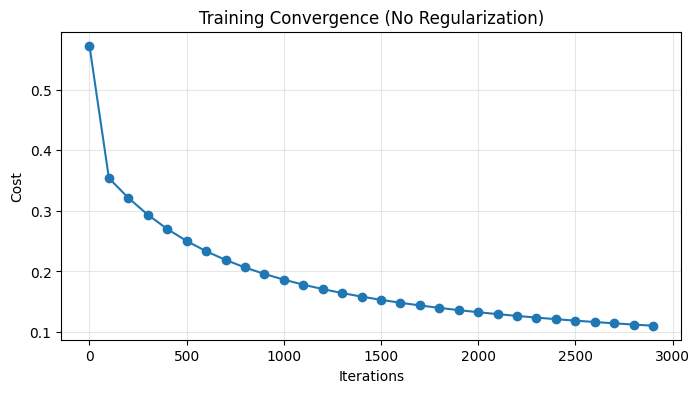

In [7]:
import matplotlib.pyplot as plt

# TODO: Initialize w to zeros (correct dimension!)
w = np.zeros(X_train_bias.shape[1])

learning_rate = 1.0
num_iterations = 3000

# TODO: Train the model
w_trained, costs = gradient_descent(X_train_bias, y_train, w, learning_rate, num_iterations)

# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(range(0, num_iterations, 100), costs, 'o-')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training Convergence (No Regularization)')
plt.grid(True, alpha=0.3)
plt.show()


## Question 7: Predictions and Evaluation

Evaluate the trained model on the test set.

**Tasks:**
- Implement `predict(X, w)`: return 1 if $\sigma(\mathbf{x}^\top\mathbf{w}) \geq 0.5$, else 0.
- Predict on the test set.
- Print accuracy, precision, recall, and F1-score for the spam class.
- Print the **confusion matrix** and briefly interpret it: what do false positives and false negatives mean in the spam-filtering context?

**Hint:** Use `sklearn.metrics` for the evaluation functions.


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# TODO: Implement predict function
def predict(X, w):
    probabilities = sigmoid(X @ w)
    predictions = (probabilities >= 0.5).astype(int)
    return predictions

# TODO: Make predictions on test set
y_pred = predict(X_test_bias, w_trained)

# TODO: Compute metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# TODO: Print confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

print("\nInterpretation:")

print("False Positives (FP): These are HAM messages wrongly classified as SPAM.")
print("-> This means a real message is blocked and user may miss important texts.")

print("\nFalse Negatives (FN): These are SPAM messages wrongly classified as HAM.")
print("-> This means spam messages go into the inbox, which is not ideal.")

print("\nFrom the confusion matrix:")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")

# TODO: Interpret — what is a false positive here? What is a false negative?

Accuracy:  0.9614
Precision: 0.9492
Recall:    0.7517
F1-score:  0.8390

Confusion Matrix:
[[960   6]
 [ 37 112]]

Interpretation:
False Positives (FP): These are HAM messages wrongly classified as SPAM.
-> This means a real message is blocked and user may miss important texts.

False Negatives (FN): These are SPAM messages wrongly classified as HAM.
-> This means spam messages go into the inbox, which is not ideal.

From the confusion matrix:
False Positives: 6
False Negatives: 37


## Question 8: L2 Regularization

L2 regularization adds a penalty on the squared magnitude of weights to prevent overfitting:

$$J_{L2}(\mathbf{w}) = J(\mathbf{w}) + \frac{\lambda}{2m}\sum_{j=1}^n w_j^2 \qquad\text{(exclude bias from penalty)}$$

Gradient adjustment: add $\frac{\lambda}{m}w_j$ to the gradient of each non-bias weight.

**Tasks:**
- Implement `compute_cost_L2` and `gradient_descent_L2`.
- Train with $\lambda \in \{0.01,\; 0.1,\; 1.0,\; 10.0\}$.
- For each $\lambda$, report test accuracy and $\|\mathbf{w}\|_2$ (excluding bias).
- Plot all cost curves on one figure.
- Comment on how $\lambda$ affects accuracy and weight magnitude.


λ= 0.01 | Accuracy: 0.9614 | ||w||₂: 25.8675
λ= 0.10 | Accuracy: 0.9605 | ||w||₂: 25.2203
λ= 1.00 | Accuracy: 0.9534 | ||w||₂: 20.1075
λ=10.00 | Accuracy: 0.8664 | ||w||₂: 6.7009


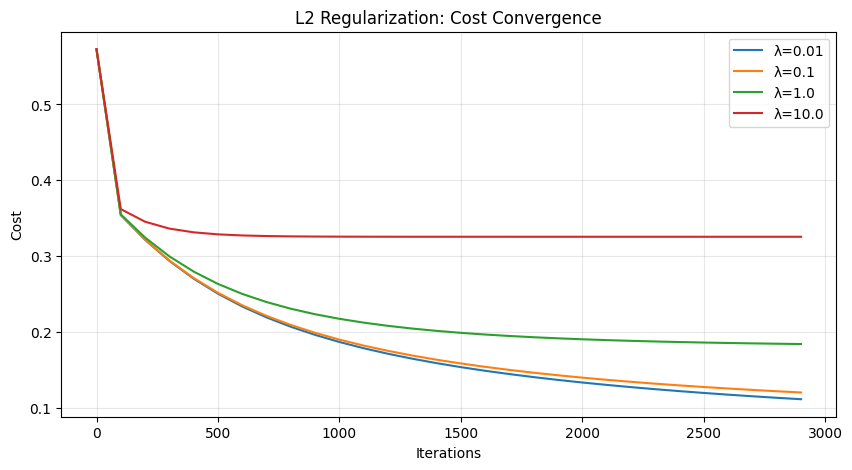


Interpretation:
As lambda increases, the L2 penalty becomes stronger.
This pushes the non-bias weights to become smaller, so ||w||_2 decreases.
A small lambda keeps accuracy high, while a very large lambda can hurt accuracy by over-regularizing the model.
In these results, lambda = 0.01 gave the best test accuracy, while lambda = 10.0 produced the smallest weight norm but much lower accuracy.


In [9]:
# TODO: Implement L2 cost
def compute_cost_L2(X, y, w, lambda_):
    m = len(y)
    h = sigmoid(X @ w)
    h = np.clip(h, 1e-7, 1 - 1e-7)
    cost = -1/m * (y @ np.log(h) + (1 - y) @ np.log(1 - h))
    cost += (lambda_ / (2 * m)) * np.sum(w[1:] ** 2)  # exclude bias
    return cost

# TODO: Implement L2 gradient descent
def gradient_descent_L2(X, y, w, learning_rate, num_iterations, lambda_):
    m = len(y)
    costs = []
    for i in range(num_iterations):
        h = sigmoid(X @ w)
        gradient = (1/m) * X.T @ (h - y)
        gradient[1:] += (lambda_ / m) * w[1:]  # regularize non-bias weights
        w = w - learning_rate * gradient
        if i % 100 == 0:
            cost = compute_cost_L2(X, y, w, lambda_)
            costs.append(cost)
    return w, costs

# Train & compare
lambda_values = [0.01, 0.1, 1.0, 10.0]
learning_rate = 1.0
num_iterations = 3000

plt.figure(figsize=(10, 5))
for lambda_ in lambda_values:
    w = np.zeros(X_train_bias.shape[1])
    w_L2, costs_L2 = gradient_descent_L2(X_train_bias, y_train, w, learning_rate, num_iterations, lambda_)
    plt.plot(range(0, num_iterations, 100), costs_L2, label=f'λ={lambda_}')
    
    y_pred_L2 = predict(X_test_bias, w_L2)
    acc = accuracy_score(y_test, y_pred_L2)
    w_norm = np.linalg.norm(w_L2[1:])  # exclude bias
    print(f"λ={lambda_:5.2f} | Accuracy: {acc:.4f} | ||w||₂: {w_norm:.4f}")

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('L2 Regularization: Cost Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nInterpretation:")
print("As lambda increases, the L2 penalty becomes stronger.")
print("This pushes the non-bias weights to become smaller, so ||w||_2 decreases.")
print("A small lambda keeps accuracy high, while a very large lambda can hurt accuracy by over-regularizing the model.")
print("In these results, lambda = 0.01 gave the best test accuracy, while lambda = 10.0 produced the smallest weight norm but much lower accuracy.")

# TODO: Comment on how lambda affects accuracy and weight magnitude


## Question 9: Model Interpretability — Top Spam/Ham Indicators

A key advantage of logistic regression is **interpretability**: each weight directly tells us how much a feature contributes to the spam probability. A large positive weight means the word pushes the prediction toward spam; a large negative weight pushes it toward ham.

**Tasks:**
- Pick the best L2 model from Question 8 (retrain with that $\lambda$ if needed) and extract the feature weights (exclude bias).
- Print the **top 20 words** with the largest positive weights (strongest spam signals).
- Print the **top 20 words** with the largest negative weights (strongest ham signals).
- Comment: do these words make intuitive sense as spam/ham indicators? Give 2–3 concrete examples.

**Hint:** Use `np.argsort` on the weight vector and index into the `vocab` list.


In [10]:
# TODO: Retrain the best L2 model (fill in the best lambda you found)
best_lambda = 0.01
w = np.zeros(X_train_bias.shape[1])
w_best, _ = gradient_descent_L2(X_train_bias, y_train, w, 1.0, 3000, best_lambda)

# Extract feature weights (exclude bias at index 0)
feature_weights = w_best[1:]

# TODO: Top 20 spam indicators (largest positive weights)
top_spam_idx = np.argsort(feature_weights)[::-1][:20]
print("=== Top 20 Spam Indicators ===")
for idx in top_spam_idx:
    print(f"  {vocab[idx]:15s}  weight = {feature_weights[idx]:.4f}")

# TODO: Top 20 ham indicators (largest negative weights)
top_ham_idx = np.argsort(feature_weights)[:20]
print("\n=== Top 20 Ham Indicators ===")
for idx in top_ham_idx:
    print(f"  {vocab[idx]:15s}  weight = {feature_weights[idx]:.4f}")

print("\nInterpretation:")
print("Yes, these words make intuitive sense as spam and ham indicators.")

print("\nExample 1:")
print("'free', 'prize', and 'claim' are strong spam words because scam messages often promise rewards or prizes.")

print("\nExample 2:")
print("'call' and 'txt' are common spam indicators because many spam texts ask users to contact a number or respond.")

print("\nExample 3:")
print("'i', 'me', 'ok', and 'sorry' are ham indicators because they are common in normal personal conversations.")

=== Top 20 Spam Indicators ===
  txt              weight = 4.7531
  call             weight = 4.1722
  free             weight = 4.0114
  claim            weight = 3.6587
  stop             weight = 3.3732
  reply            weight = 3.1599
  mobile           weight = 3.1390
  text             weight = 3.0568
  prize            weight = 2.7377
  won              weight = 2.7124
  to               weight = 2.7111
  service          weight = 2.6887
  from             weight = 2.6123
  win              weight = 2.4767
  urgent           weight = 2.4312
  2                weight = 2.1415
  our              weight = 2.1266
  per              weight = 1.9418
  cash             weight = 1.9395
  chat             weight = 1.9336

=== Top 20 Ham Indicators ===
  i                weight = -5.1055
  me               weight = -3.2814
  my               weight = -3.0532
  im               weight = -2.8323
  ill              weight = -2.1756
  ltgt             weight = -2.1390
  in               wei

## Question 10: Threshold Tuning and the Precision–Recall Trade-off

By default we classify a message as spam when $\sigma(\mathbf{x}^\top\mathbf{w}) \geq 0.5$. But in practice the threshold can be tuned. Lowering it catches more spam (higher recall) but risks more false positives (lower precision), and vice versa.

**Tasks:**
- Using the best L2 model from Q9, compute the predicted **probabilities** on the test set.
- For thresholds $t \in \{0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9\}$, compute precision, recall, and F1 for the spam class and print them in a table.
- Plot **precision vs. recall** (one point per threshold) and label each point with its threshold value.
- Answer: if you were building a spam filter for a **medical alert system** where blocking a legitimate message is dangerous, would you raise or lower the threshold? Why?

**Hint:** Use `sigmoid(X_test_bias @ w_best)` to get probabilities, then `(probs >= t).astype(int)` for each threshold.


 Threshold  Precision     Recall         F1
--------------------------------------------
       0.1     0.5975     0.9664     0.7385
       0.2     0.8092     0.9396     0.8696
       0.3     0.9048     0.8926     0.8986
       0.4     0.9389     0.8255     0.8786
       0.5     0.9492     0.7517     0.8390
       0.6     0.9899     0.6577     0.7903
       0.7     1.0000     0.5638     0.7210
       0.8     1.0000     0.3826     0.5534
       0.9     1.0000     0.1208     0.2156


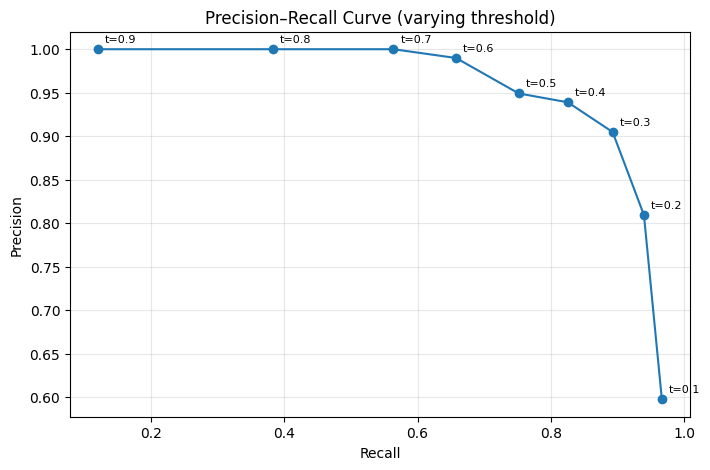


Interpretation:
As the threshold increases, precision increases but recall decreases.
As the threshold decreases, recall increases but precision decreases.

Medical alert system decision:
We should RAISE the threshold.
Reason: In a medical alert system, blocking a real legitimate message is dangerous.
A higher threshold reduces false positives, so fewer real alerts are incorrectly marked as spam.
It is safer to let some spam pass through than to block an important medical message.


In [11]:
# Compute probabilities on test set
probs = sigmoid(X_test_bias @ w_best)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
precisions = []
recalls = []

print(f"{'Threshold':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 44)

for t in thresholds:
    # TODO: Compute predictions at this threshold
    y_pred_t = (probs >= t).astype(int)
    
    # TODO: Compute precision, recall, F1
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    precisions.append(p)
    recalls.append(r)
    print(f"{t:10.1f} {p:10.4f} {r:10.4f} {f:10.4f}")

# TODO: Plot Precision vs Recall curve
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, 'o-')
for i, t in enumerate(thresholds):
    plt.annotate(f't={t}', (recalls[i], precisions[i]), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (varying threshold)')
plt.grid(True, alpha=0.3)
plt.show()

print("\nInterpretation:")
print("As the threshold increases, precision increases but recall decreases.")
print("As the threshold decreases, recall increases but precision decreases.")

print("\nMedical alert system decision:")
print("We should RAISE the threshold.")
print("Reason: In a medical alert system, blocking a real legitimate message is dangerous.")
print("A higher threshold reduces false positives, so fewer real alerts are incorrectly marked as spam.")
print("It is safer to let some spam pass through than to block an important medical message.")

## Question 11: Conceptual Questions

Answer the following in the markdown cell below.

**a)** Why do we use the sigmoid function to wrap the linear output $\mathbf{x}^\top\mathbf{w}$ instead of using it directly for binary classification? What property of the sigmoid makes it suitable?

**b)** Explain intuitively why L2 regularization helps prevent overfitting. What happens to the decision boundary as $\lambda$ increases?

**c)** In Question 10 you observed the precision–recall trade-off. Explain why precision and recall move in opposite directions as the threshold changes. Is there always a threshold that maximizes both simultaneously?


**Your Answers:**

a) The sigmoid function takes the raw number output and squashes it between 0 and 1
so we can treat it like a probability. Without it the output could be any number
which makes no sense for classification. Also sigmoid is smooth so gradient descent can actually compute the slope and update the weights properly during training. The sigmoid function is also differentiable everywhere, which makes it suitable for optimization using gradient descent.

b) Without regularization the model just memorizes the training data by making some
weights really large. L2 adds a penalty for big weights so the model is forced to keep them small and more general. In our Q8 results when lambda went from 0.01 to 10 the weights dropped from 25.87 to 6.70 but accuracy also dropped from 96.1% to 86.6% so too much regularization makes the model too simple and it starts missing things.

c) When you lower the threshold the model calls more messages spam so it catches more
actual spam but also wrongly flags more real messages. When you raise it the model
is more careful so fewer real messages get blocked but more spam slips through.
In our Q10 results at t=0.1 recall was 96.6% but precision was only 59%
and at t=0.9 precision hit 100% but recall fell to 12%. You cant maximize both
at the same time the best balance we found was at t=0.3 with F1 of 0.8986. This trade-off exists because changing the threshold shifts the decision boundary, affecting how many positives are predicted.